In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn

import joblib

print("Everything Installed Successfully")

Everything Installed Successfully


Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load the Dataset

In [3]:
df = pd.read_csv("../Dataset/student_data.csv")

In [4]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [5]:
df.shape

(395, 33)

In [6]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [8]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [9]:
df.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,10,15,15,15
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,12,12,11
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,6,6,5,6
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,16,18,19
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,14,15,15


In [10]:
df.tail()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10
394,MS,M,19,U,LE3,T,1,1,other,at_home,...,3,2,3,3,3,5,5,8,9,9


In [11]:
df.sample(5)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
364,MS,F,17,R,GT3,T,1,2,other,services,...,3,2,2,1,2,3,0,12,11,12
226,GP,F,17,U,GT3,T,3,2,other,other,...,5,3,4,1,3,3,10,16,15,15
32,GP,M,15,R,GT3,T,4,3,teacher,at_home,...,4,5,2,1,1,5,0,17,16,16
304,GP,M,19,U,GT3,T,3,3,other,other,...,4,4,4,1,1,3,20,15,14,13
340,GP,F,19,U,GT3,T,2,1,services,services,...,4,3,4,1,3,3,4,11,12,11


In [12]:
df.dtypes

school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object

Data Cleaning

In [13]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.nunique()

school         2
sex            2
age            8
address        2
famsize        2
Pstatus        2
Medu           5
Fedu           5
Mjob           5
Fjob           5
reason         4
guardian       3
traveltime     4
studytime      4
failures       4
schoolsup      2
famsup         2
paid           2
activities     2
nursery        2
higher         2
internet       2
romantic       2
famrel         5
freetime       5
goout          5
Dalc           5
Walc           5
health         5
absences      34
G1            17
G2            17
G3            18
dtype: int64

In [16]:
df.dtypes

school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object

In [17]:
df["G3"].describe()

count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64

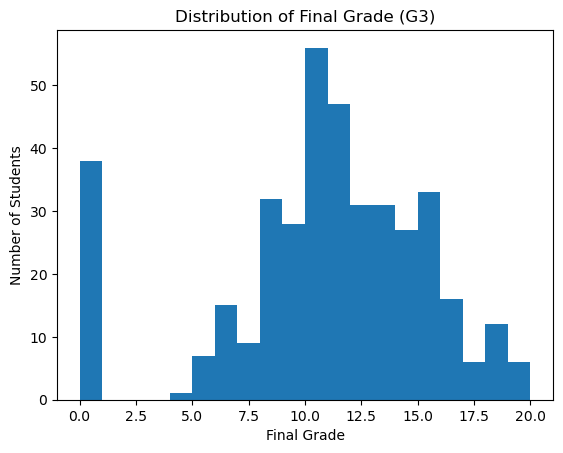

In [18]:
import matplotlib.pyplot as plt

plt.hist(df["G3"], bins=20)
plt.title("Distribution of Final Grade (G3)")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")
plt.show()

In [19]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


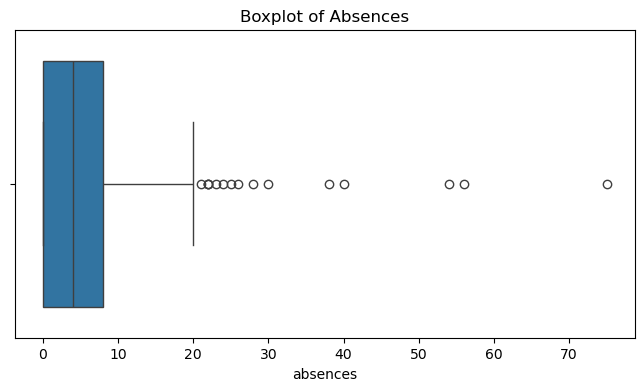

In [20]:
import seaborn as sns

plt.figure(figsize=(8,4))
sns.boxplot(x=df["absences"])
plt.title("Boxplot of Absences")
plt.show()

Encoding Categorical Features

In [21]:
df.select_dtypes(include="object").columns

Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object')

In [22]:
df["sex"].unique()

array(['F', 'M'], dtype=object)

In [23]:
df["school"].unique()

array(['GP', 'MS'], dtype=object)

In [24]:
df["internet"].unique()

array(['no', 'yes'], dtype=object)

In [25]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in df.select_dtypes(include="object").columns:
    df[column] = le.fit_transform(df[column])

In [26]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,0,0,18,1,0,0,4,4,0,4,...,4,3,4,1,1,3,6,5,6,6
1,0,0,17,1,0,1,1,1,0,2,...,5,3,3,1,1,3,4,5,5,6
2,0,0,15,1,1,1,1,1,0,2,...,4,3,2,2,3,3,10,7,8,10
3,0,0,15,1,0,1,4,2,1,3,...,3,2,2,1,1,5,2,15,14,15
4,0,0,16,1,0,1,3,3,2,2,...,4,3,2,1,2,5,4,6,10,10


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    int64
 1   sex         395 non-null    int64
 2   age         395 non-null    int64
 3   address     395 non-null    int64
 4   famsize     395 non-null    int64
 5   Pstatus     395 non-null    int64
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    int64
 9   Fjob        395 non-null    int64
 10  reason      395 non-null    int64
 11  guardian    395 non-null    int64
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    int64
 16  famsup      395 non-null    int64
 17  paid        395 non-null    int64
 18  activities  395 non-null    int64
 19  nursery     395 non-null    int64
 20  higher      395 non-null    int6

Exploratory Data Analysis (EDA)

In [28]:
df.to_csv("../Dataset/student_data_cleaned.csv", index=False)

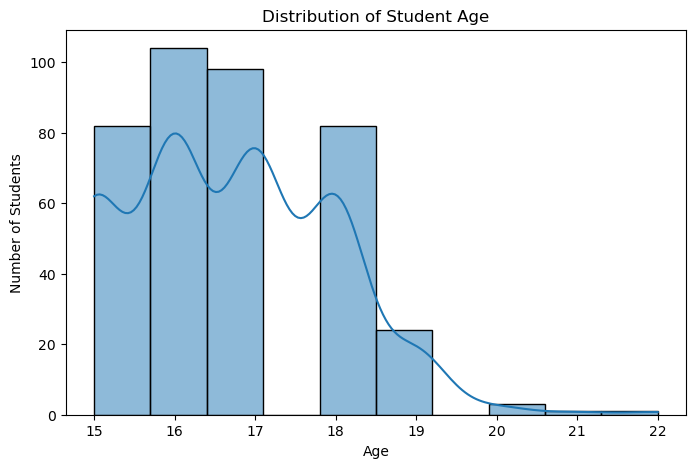

In [29]:
plt.figure(figsize=(8,5))

sns.histplot(df["age"], bins=10, kde=True)

plt.title("Distribution of Student Age")

plt.xlabel("Age")

plt.ylabel("Number of Students")

plt.show()

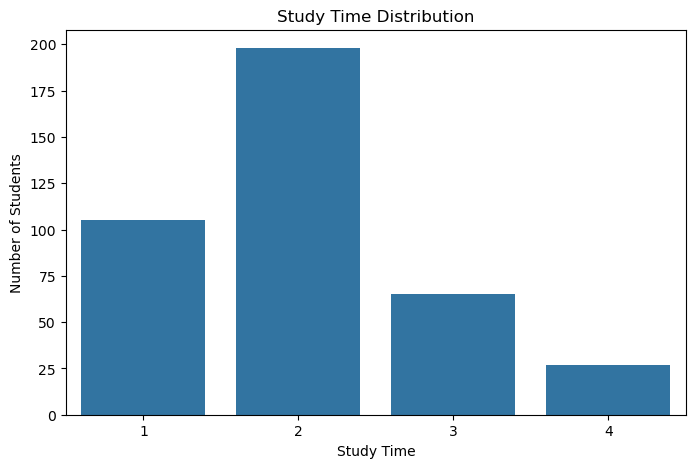

In [30]:
plt.figure(figsize=(8,5))

sns.countplot(x="studytime", data=df)

plt.title("Study Time Distribution")

plt.xlabel("Study Time")

plt.ylabel("Number of Students")

plt.show()

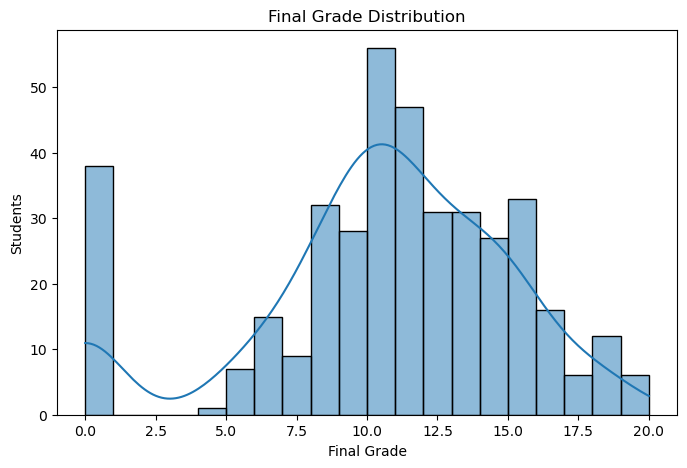

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(df["G3"], bins=20, kde=True)

plt.title("Final Grade Distribution")

plt.xlabel("Final Grade")

plt.ylabel("Students")

plt.show()

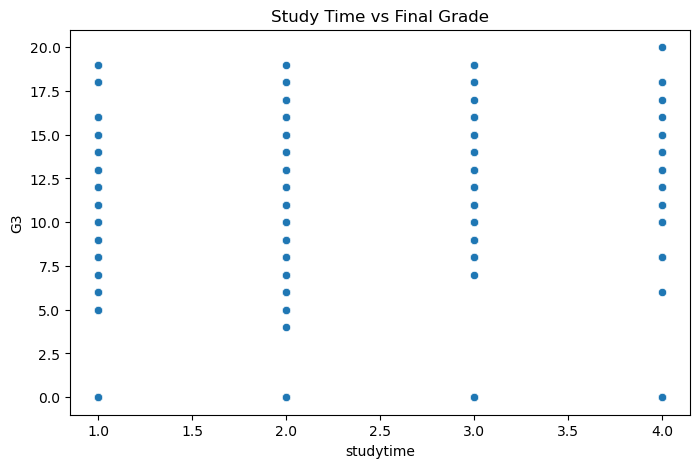

In [32]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="studytime", y="G3", data=df)

plt.title("Study Time vs Final Grade")

plt.show()

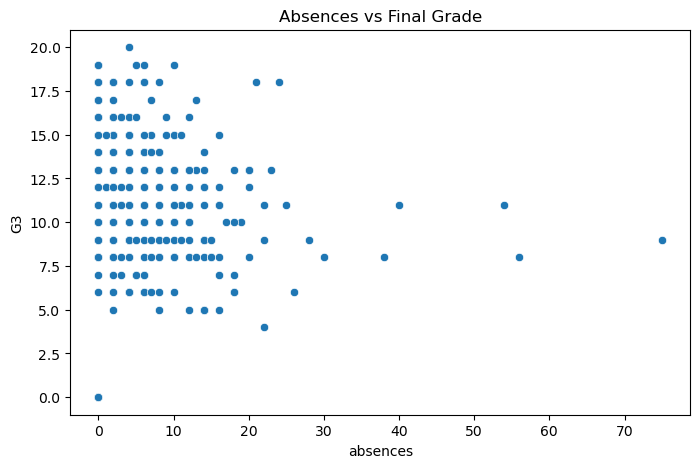

In [33]:
plt.figure(figsize=(8,5))

sns.scatterplot(x="absences", y="G3", data=df)

plt.title("Absences vs Final Grade")

plt.show()

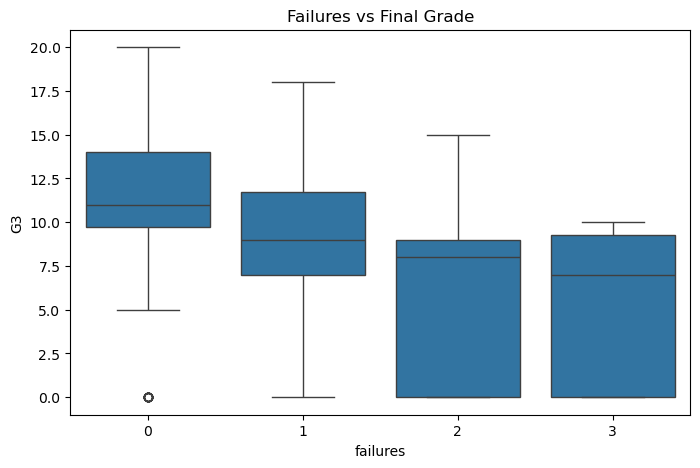

In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(x="failures", y="G3", data=df)

plt.title("Failures vs Final Grade")

plt.show()

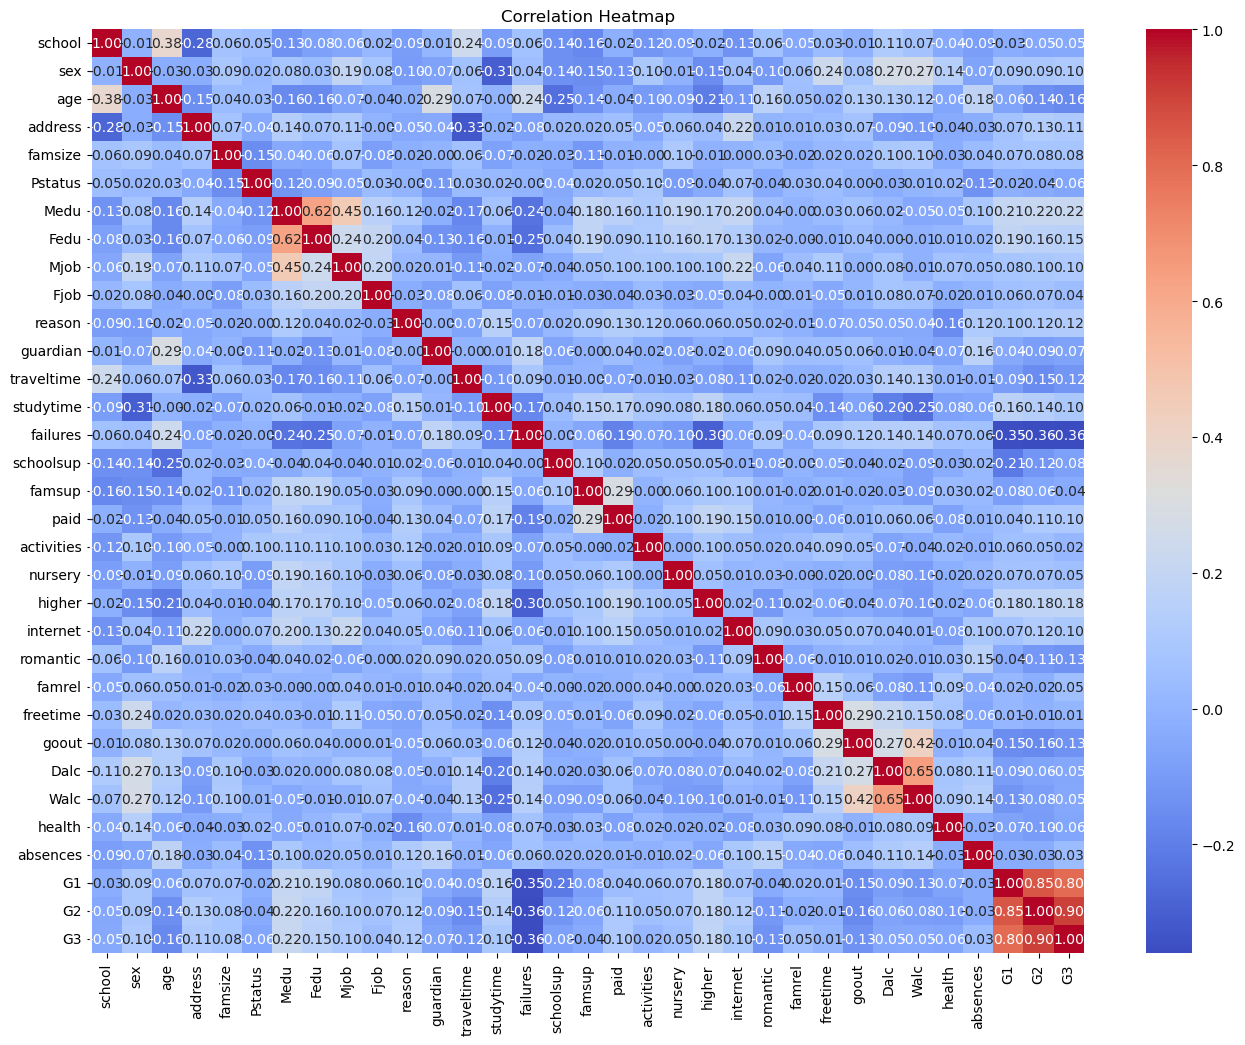

In [35]:
plt.figure(figsize=(16,12))

correlation = df.corr()

sns.heatmap(correlation,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

In [36]:
df_fe = df.copy()

In [37]:
df_fe["AverageGrade"] = (df_fe["G1"] + df_fe["G2"]) / 2

In [38]:
df_fe.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,AverageGrade
0,0,0,18,1,0,0,4,4,0,4,...,3,4,1,1,3,6,5,6,6,5.5
1,0,0,17,1,0,1,1,1,0,2,...,3,3,1,1,3,4,5,5,6,5.0
2,0,0,15,1,1,1,1,1,0,2,...,3,2,2,3,3,10,7,8,10,7.5
3,0,0,15,1,0,1,4,2,1,3,...,2,2,1,1,5,2,15,14,15,14.5
4,0,0,16,1,0,1,3,3,2,2,...,3,2,1,2,5,4,6,10,10,8.0


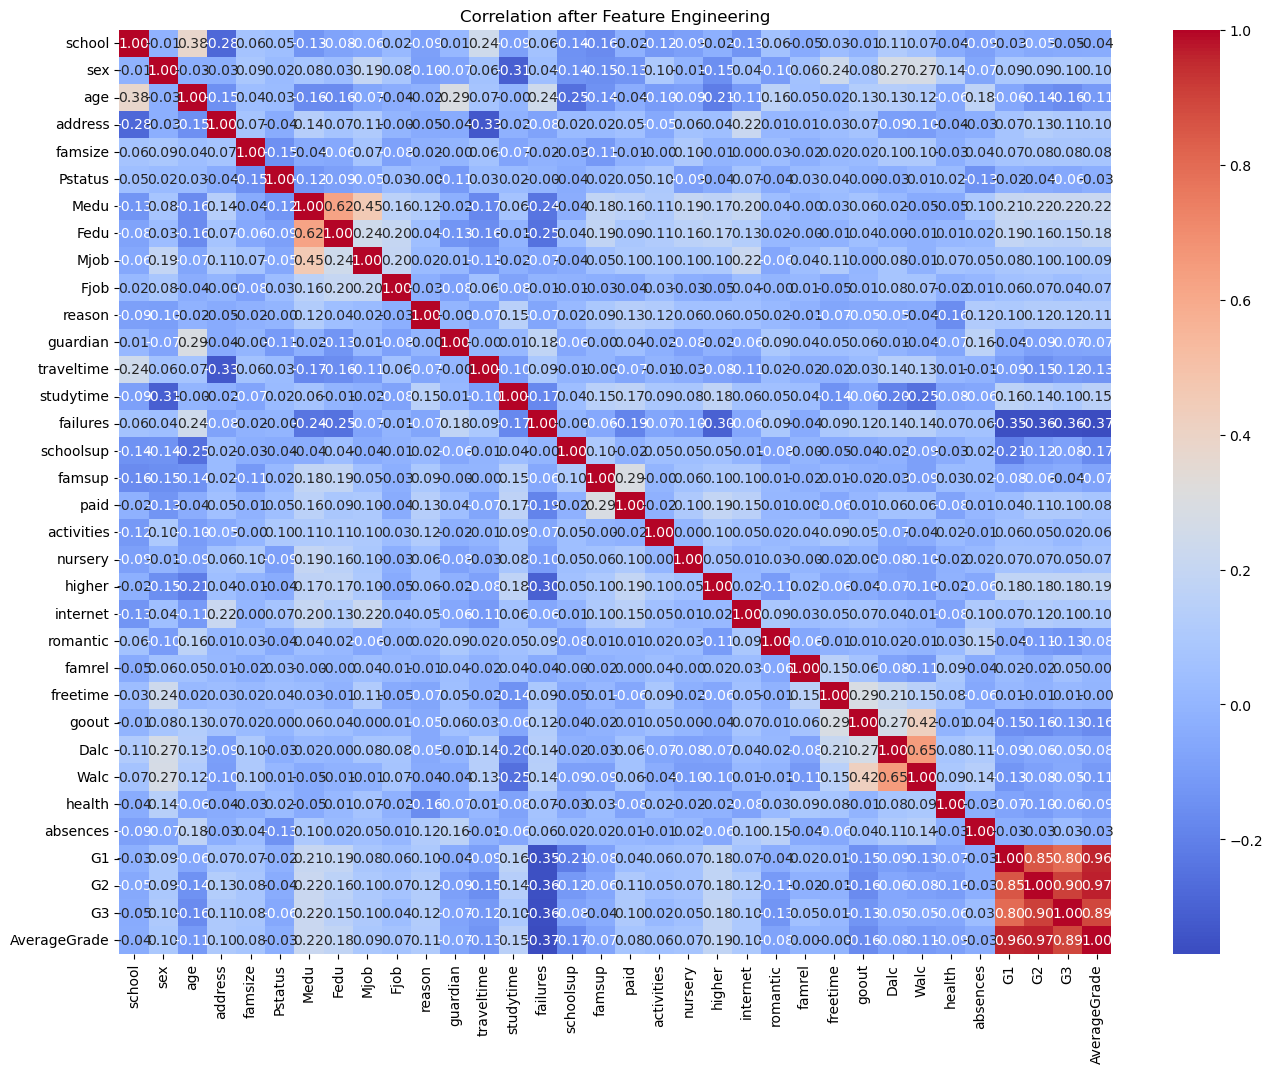

In [39]:
plt.figure(figsize=(16,12))

corr = df_fe.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation after Feature Engineering")

plt.show()

In [40]:
corr_with_target = df_fe.corr()["G3"].sort_values(ascending=False)

print(corr_with_target)

G3              1.000000
G2              0.904868
AverageGrade    0.889792
G1              0.801468
Medu            0.217147
higher          0.182465
Fedu            0.152457
reason          0.121994
address         0.105756
sex             0.103456
Mjob            0.102082
paid            0.101996
internet        0.098483
studytime       0.097820
famsize         0.081407
nursery         0.051568
famrel          0.051363
Fjob            0.042286
absences        0.034247
activities      0.016100
freetime        0.011307
famsup         -0.039157
school         -0.045017
Walc           -0.051939
Dalc           -0.054660
Pstatus        -0.058009
health         -0.061335
guardian       -0.070109
schoolsup      -0.082788
traveltime     -0.117142
romantic       -0.129970
goout          -0.132791
age            -0.161579
failures       -0.360415
Name: G3, dtype: float64


In [41]:
df_fe.drop("school", axis=1, inplace=True)

In [42]:
df_fe.to_csv("../Dataset/student_data_feature_engineered.csv", index=False)

In [43]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import joblib

In [44]:
X = df.drop(columns=["G3"])

y = df["G3"]

In [45]:
X = df.drop(columns=["G1","G2","G3"])

In [46]:
X.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences
0,0,0,18,1,0,0,4,4,0,4,...,1,0,0,4,3,4,1,1,3,6
1,0,0,17,1,0,1,1,1,0,2,...,1,1,0,5,3,3,1,1,3,4
2,0,0,15,1,1,1,1,1,0,2,...,1,1,0,4,3,2,2,3,3,10
3,0,0,15,1,0,1,4,2,1,3,...,1,1,1,3,2,2,1,1,5,2
4,0,0,16,1,0,1,3,3,2,2,...,1,0,0,4,3,2,1,2,5,4


In [47]:
y.head()

0     6
1     6
2    10
3    15
4    10
Name: G3, dtype: int64

In [48]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

In [49]:
print(X_train.shape)

print(X_test.shape)

print(y_train.shape)

print(y_test.shape)

(316, 30)
(79, 30)
(316,)
(79,)


In [50]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [51]:
linear_prediction = linear_model.predict(X_test)

In [52]:
print(linear_prediction[:10])

[ 3.19064116  7.6306416   8.80166265 11.68847066  8.88212666 10.0508523
 11.20318607 13.30707454  9.09346232 11.56597276]


In [53]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [54]:
rf_prediction = rf_model.predict(X_test)

In [55]:
xgb_model = XGBRegressor(
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [56]:
xgb_prediction = xgb_model.predict(X_test)

In [57]:
lr_mae = mean_absolute_error(y_test, linear_prediction)

lr_mse = mean_squared_error(y_test, linear_prediction)

lr_rmse = mean_squared_error(y_test, linear_prediction) ** 0.5

lr_r2 = r2_score(y_test, linear_prediction)

print("Linear Regression")

print("MAE :", lr_mae)

print("MSE :", lr_mse)

print("RMSE:", lr_rmse)

print("R2 :", lr_r2)

Linear Regression
MAE : 3.4948497013642124
MSE : 18.54365366145742
RMSE: 4.306234278514979
R2 : 0.09565418606292198


In [58]:
rf_mae = mean_absolute_error(y_test, rf_prediction)

rf_mse = mean_squared_error(y_test, rf_prediction)

rf_rmse = mean_squared_error(y_test, rf_prediction) ** 0.5

rf_r2 = r2_score(y_test, rf_prediction)

print("Random Forest")

print("MAE :", rf_mae)

print("MSE :", rf_mse)

print("RMSE:", rf_rmse)

print("R2 :", rf_r2)

Random Forest
MAE : 2.995822784810126
MSE : 13.826345569620255
RMSE: 3.718379427871805
R2 : 0.3257101342481168


In [59]:
xgb_mae = mean_absolute_error(y_test, xgb_prediction)

xgb_mse = mean_squared_error(y_test, xgb_prediction)

xgb_rmse = mean_squared_error(y_test, xgb_prediction) ** 0.5

xgb_r2 = r2_score(y_test, xgb_prediction)

print("XGBoost")

print("MAE :", xgb_mae)

print("MSE :", xgb_mse)

print("RMSE:", xgb_rmse)

print("R2 :", xgb_r2)

XGBoost
MAE : 3.064858913421631
MSE : 13.977503776550293
RMSE: 3.738649993854773
R2 : 0.31833845376968384


In [60]:
import pandas as pd

results = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],

    "MAE": [
        lr_mae,
        rf_mae,
        xgb_mae
    ],

    "MSE": [
        lr_mse,
        rf_mse,
        xgb_mse
    ],

    "RMSE": [
        lr_rmse,
        rf_rmse,
        xgb_rmse
    ],

    "R2 Score": [
        lr_r2,
        rf_r2,
        xgb_r2
    ]

})

results

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,3.494850,18.543654,4.306234,0.095654
1,Random Forest,2.995823,13.826346,3.718379,0.325710
2,XGBoost,3.064859,13.977504,3.738650,0.318338


In [61]:
joblib.dump(rf_model, "../Model/student_model.pkl")

['../Model/student_model.pkl']

In [62]:
import os

print(os.listdir("../Model"))

['student_model.pkl']


In [63]:
new_df = pd.DataFrame()

In [64]:
new_df["Gender"] = df["sex"]

In [65]:
new_df["Age"] = df["age"]

In [66]:
study_mapping = {
    1: 1,
    2: 3,
    3: 5,
    4: 7
}

new_df["Self_Study_Hours"] = df["studytime"].map(study_mapping)

In [67]:
new_df["Previous_Failures"] = df["failures"]

In [68]:
new_df["Extra_Classes"] = df["schoolsup"]

In [69]:
new_df["Attendance_Percentage"] = 100 - df["absences"]

In [70]:
new_df["Attendance_Percentage"] = new_df["Attendance_Percentage"].clip(lower=0, upper=100)

In [71]:
new_df["Assignments_Submitted"] = (
    (df["studytime"] * 2 + df["higher"] * 2)
).clip(0, 10)

In [72]:
new_df["Internal_Marks"] = (df["G3"] / 2).round()

In [73]:
new_df["Final_Score"] = df["G3"] * 5

In [74]:
new_df["Student_Name"] = [
    f"Student {i+1}" for i in range(len(new_df))
]

In [75]:
new_df = new_df[
[
"Student_Name",
"Gender",
"Age",
"Assignments_Submitted",
"Internal_Marks",
"Attendance_Percentage",
"Self_Study_Hours",
"Previous_Failures",
"Extra_Classes",
"Final_Score"
]
]

In [76]:
new_df.head()

,Student_Name,Gender,Age,Assignments_Submitted,Internal_Marks,Attendance_Percentage,Self_Study_Hours,Previous_Failures,Extra_Classes,Final_Score
0,Student 1,0,18,6,3.0,94,3,0,1,30
1,Student 2,0,17,6,3.0,96,3,0,0,30
2,Student 3,0,15,6,5.0,90,3,3,1,50
3,Student 4,0,15,8,8.0,98,5,0,0,75
4,Student 5,0,16,6,5.0,96,3,0,0,50


In [77]:
new_df.to_csv("../Dataset/student_performance_final.csv", index=False)

In [78]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_Name           395 non-null    object 
 1   Gender                 395 non-null    int64  
 2   Age                    395 non-null    int64  
 3   Assignments_Submitted  395 non-null    int64  
 4   Internal_Marks         395 non-null    float64
 5   Attendance_Percentage  395 non-null    int64  
 6   Self_Study_Hours       395 non-null    int64  
 7   Previous_Failures      395 non-null    int64  
 8   Extra_Classes          395 non-null    int64  
 9   Final_Score            395 non-null    int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 31.0+ KB


In [79]:
X = new_df.drop(["Student_Name", "Final_Score"], axis=1)

y = new_df["Final_Score"]

In [80]:
X.head()

,Gender,Age,Assignments_Submitted,Internal_Marks,Attendance_Percentage,Self_Study_Hours,Previous_Failures,Extra_Classes
0,0,18,6,3.0,94,3,0,1
1,0,17,6,3.0,96,3,0,0
2,0,15,6,5.0,90,3,3,1
3,0,15,8,8.0,98,5,0,0
4,0,16,6,5.0,96,3,0,0


In [81]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [82]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [83]:
prediction = model.predict(X_test)

In [84]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, prediction)

mse = mean_squared_error(y_test, prediction)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, prediction)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 2.021710367691381
MSE : 10.830006707909954
RMSE: 3.2908975535421874
R2 Score: 0.9788734811164737


In [85]:
import joblib

joblib.dump(model, "../Model/student_model.pkl")

['../Model/student_model.pkl']